# Sales Forecasting Project — Swati Shahi

# Task 1: Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("train.csv")

print("Raw shape:", df.shape)
print("\nColumns:", list(df.columns))

Raw shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [3]:
#parse dates
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [4]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(month_to_season)

In [5]:
# 4. DATA QUALITY CHECKS

print("\n--- Missing values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Duplicate rows ---")
print("Exact duplicate rows:", df.duplicated().sum())

print("\n--- Data types ---")
print(df.dtypes)


--- Missing values ---
Postal Code    11
dtype: int64

--- Duplicate rows ---
Exact duplicate rows: 0

--- Data types ---
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Week Number              UInt32
Day of Week                 str
Quarter                   int32
Season                      str
dtype: object


In [6]:
# 5. AGGREGATE TO WEEKLY AND MONTHLY TOTALS

daily_sales = df.groupby("Order Date")["Sales"].sum().sort_index()

weekly_sales = daily_sales.resample("W").sum()
monthly_sales = daily_sales.resample("MS").sum()  # MS = Month Start

weekly_sales.to_csv("weekly_sales.csv", header=["Sales"])
monthly_sales.to_csv("monthly_sales.csv", header=["Sales"])

print("\nWeekly sales series shape:", weekly_sales.shape)
print("Monthly sales series shape:", monthly_sales.shape)


Weekly sales series shape: (209,)
Monthly sales series shape: (48,)


In [7]:
# 6. ANSWER THE REQUIRED EDA QUESTIONS

print("\n" + "="*60)
print("Q1: Which product category generates the highest total revenue?")
print("="*60)
cat_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(cat_revenue)
print(f"-> Answer: {cat_revenue.index[0]} (${cat_revenue.iloc[0]:,.2f})")

print("\n" + "="*60)
print("Q2: Which region has the most CONSISTENT sales growth over 4 years?")
print("="*60)
region_yearly = df.groupby(["Region", "Year"])["Sales"].sum().unstack("Region")
region_growth = region_yearly.pct_change().dropna()
consistency = region_growth.std().sort_values()
print("Year-over-year growth rate by region:\n", region_growth)
print("\nStd deviation of growth rate (lower = more consistent):\n", consistency)
print(f"-> Answer: {consistency.index[0]} shows the most consistent growth pattern")

print("\n" + "="*60)
print("Q3: Average time between Order Date and Ship Date — does it vary by region?")
print("="*60)
df["Shipping Delay (days)"] = (df["Ship Date"] - df["Order Date"]).dt.days
overall_avg_delay = df["Shipping Delay (days)"].mean()
delay_by_region = df.groupby("Region")["Shipping Delay (days)"].mean().sort_values()
print(f"Overall average shipping delay: {overall_avg_delay:.2f} days")
print("\nAverage delay by region:\n", delay_by_region)

print("\n" + "="*60)
print("Q4: Are there months that consistently spike across all years (seasonality)?")
print("="*60)
monthly_by_year = df.groupby(["Year", "Month"])["Sales"].sum().unstack("Year")
avg_by_month = monthly_by_year.mean(axis=1).sort_values(ascending=False)
print("Average sales by calendar month (across all years):\n", avg_by_month)
print(f"-> Top spiking months: {list(avg_by_month.index[:2])}")

print("\nTask 1 complete. Files written: weekly_sales.csv, monthly_sales.csv")


Q1: Which product category generates the highest total revenue?
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
-> Answer: Technology ($827,455.87)

Q2: Which region has the most CONSISTENT sales growth over 4 years?
Year-over-year growth rate by region:
 Region   Central      East     South      West
Year                                          
2016   -0.004813  0.200327 -0.322117 -0.083603
2017    0.422247  0.165027  0.334776  0.364683
2018   -0.027778  0.177118  0.306071  0.359836

Std deviation of growth rate (lower = more consistent):
 Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64
-> Answer: East shows the most consistent growth pattern

Q3: Average time between Order Date and Ship Date — does it vary by region?
Overall average shipping delay: 3.96 days

Average delay by region:
 Region
East       3.910233
West       3.930255
South      3.961

### Task 1 — EDA Findings

**Q1:** Technology generates the highest total revenue (~$827,455.87), narrowly ahead of Furniture (~$728,658) and Office Supplies (~$705,422).

**Q2:** The East region shows the most consistent year-over-year growth (std deviation 0.018), far more stable than Central (0.253), South, or West — even though it isn't necessarily the fastest-growing region.

**Q3:** Average shipping delay is ~3.96 days overall, and it barely varies by region — shipping delay is not a meaningful regional differentiator in this dataset.

**Q4:** November and December show a clear seasonal spike across all years, consistent with holiday shopping season.

# Task 2: Time Series Decomposition & Stationarity Testing

Monthly sales series:
Order Date
2015-01-01     14205.7070
2015-02-01      4519.8920
2015-03-01     55205.7970
2015-04-01     27906.8550
2015-05-01     23644.3030
2015-06-01     34322.9356
2015-07-01     33781.5430
2015-08-01     27117.5365
2015-09-01     81623.5268
2015-10-01     31453.3930
2015-11-01     77907.6607
2015-12-01     68167.0585
2016-01-01     18066.9576
2016-02-01     11951.4110
2016-03-01     32339.3184
2016-04-01     34154.4685
2016-05-01     29959.5305
2016-06-01     23599.3740
2016-07-01     28608.2590
2016-08-01     36818.3422
2016-09-01     63133.6060
2016-10-01     31011.7375
2016-11-01     75249.3995
2016-12-01     74543.6012
2017-01-01     18542.4910
2017-02-01     22978.8150
2017-03-01     51165.0590
2017-04-01     38679.7670
2017-05-01     56656.9080
2017-06-01     39724.4860
2017-07-01     38320.7830
2017-08-01     30542.2003
2017-09-01     69193.3909
2017-10-01     59583.0330
2017-11-01     79066.4958
2017-12-01     95739.1210
2018-01-01     43476.4740
2018-

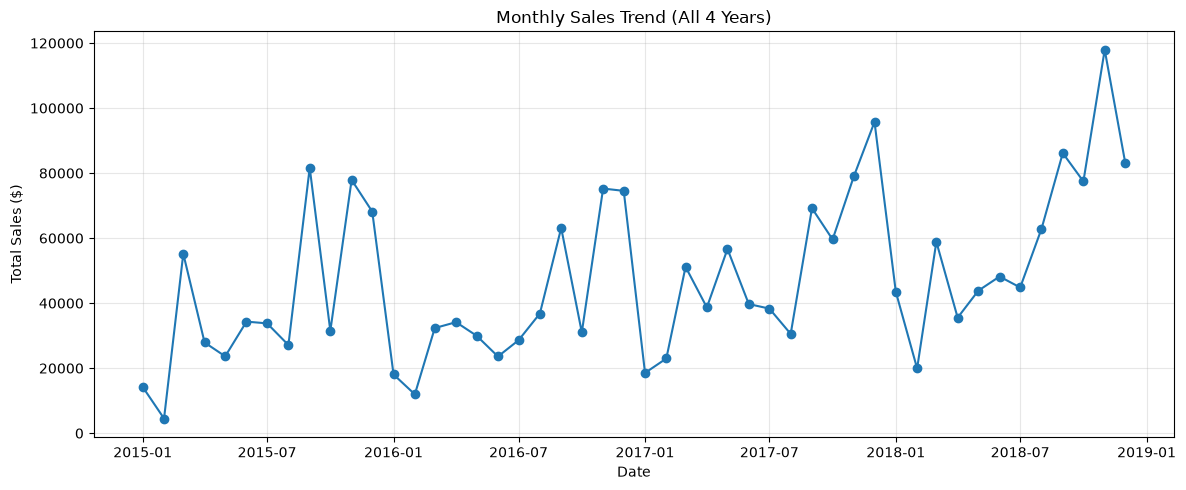

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

monthly_sales = pd.read_csv("monthly_sales.csv", index_col=0, parse_dates=True)
monthly_sales = monthly_sales["Sales"]
monthly_sales.index.freq = "MS"

print("Monthly sales series:")
print(monthly_sales)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend (All 4 Years)")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png", dpi=150)
plt.show()

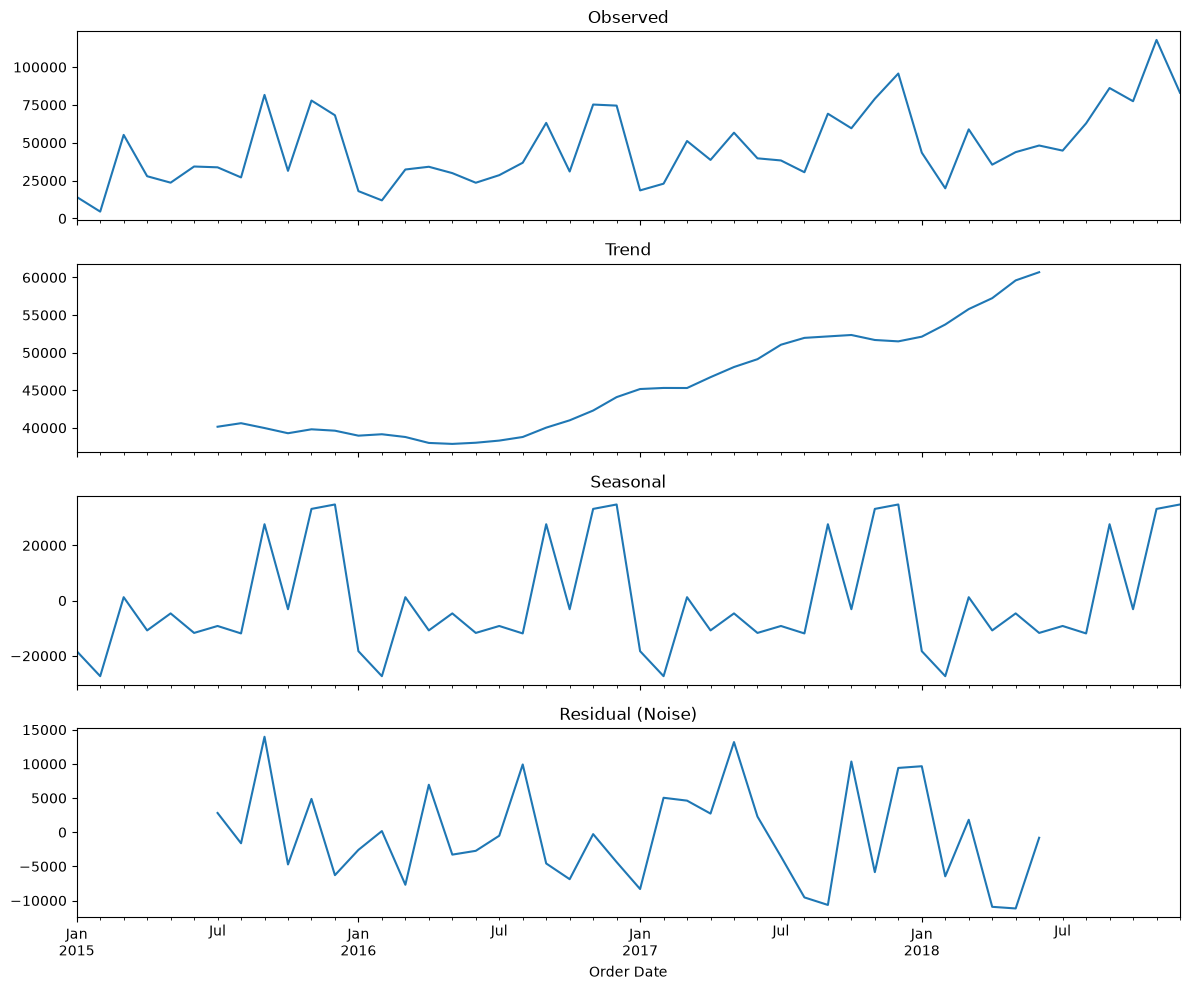


Trend range: $22,834.82
Seasonal swing (peak-to-trough): $62,195.01
Residual (noise) std deviation: $7,040.94

Average absolute residual by calendar month (higher = noisier/harder to predict):
Order Date
9     9728.547556
5     9209.978697
10    7313.171149
8     7025.303538
4     6863.380981
1     6852.873043
12    6687.857530
3     4711.500911
2     3887.845179
11    3665.421103
7     2293.163589
6     1941.363737
Name: resid, dtype: float64


In [30]:
# TIME SERIES DECOMPOSITION

decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual (Noise)")
plt.tight_layout()
plt.savefig("charts/decomposition.png", dpi=150)
plt.show()

trend_range = decomposition.trend.max() - decomposition.trend.min()
seasonal_range = decomposition.seasonal.max() - decomposition.seasonal.min()
resid_std = decomposition.resid.std()

print(f"\nTrend range: ${trend_range:,.2f}")
print(f"Seasonal swing (peak-to-trough): ${seasonal_range:,.2f}")
print(f"Residual (noise) std deviation: ${resid_std:,.2f}")

resid_by_month = decomposition.resid.dropna()
resid_by_month = resid_by_month.groupby(resid_by_month.index.month).apply(lambda x: x.abs().mean())
resid_by_month = resid_by_month.sort_values(ascending=False)
print("\nAverage absolute residual by calendar month (higher = noisier/harder to predict):")
print(resid_by_month)

In [31]:
# STATIONARITY TEST (Augmented Dickey-Fuller)

def run_adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    for key, value in result[4].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result[1] < 0.05:
        print(f"-> p-value < 0.05: series IS stationary")
    else:
        print(f"-> p-value >= 0.05: series is NOT stationary")
    return result[1]

p_value_raw = run_adf_test(monthly_sales, "Raw monthly sales")

if p_value_raw >= 0.05:
    monthly_sales_diff = monthly_sales.diff().dropna()

    plt.figure(figsize=(12, 4))
    plt.plot(monthly_sales_diff.index, monthly_sales_diff.values, marker="o", color="orange")
    plt.title("Differenced Monthly Sales (d=1)")
    plt.axhline(0, color="gray", linestyle="--")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("charts/differenced_series.png", dpi=150)
    plt.show()

    p_value_diff = run_adf_test(monthly_sales_diff, "Differenced monthly sales (d=1)")

    if p_value_diff < 0.05:
        print("\n-> One round of differencing (d=1) is enough to achieve stationarity.")
    else:
        print("\n-> Still non-stationary after d=1 — consider a second differencing pass (d=2).")
else:
    print("\n-> Raw series was already stationary; no differencing needed (d=0).")


--- ADF Test: Raw monthly sales ---
ADF Statistic: -4.4161
p-value: 0.0003
   Critical Value (1%): -3.5778
   Critical Value (5%): -2.9253
   Critical Value (10%): -2.6008
-> p-value < 0.05: series IS stationary

-> Raw series was already stationary; no differencing needed (d=0).


### Task 2 — Observations

1. **Trend:** Sales grew steadily from ~$40K/month in 2015 to ~$60K/month in 2018 (trend range: $22,834.82) — real underlying business growth.
2. **Seasonality:** Seasonal swing ($62,195.01) is larger than the trend range, meaning calendar-driven seasonality (Nov/Dec spikes) is the dominant source of month-to-month variation, not growth.
3. **Noise:** Residual std deviation ($7,040.94) is small relative to trend and seasonality — the pattern is fairly predictable once seasonality is accounted for. September and May are the noisiest (least predictable) months; November, despite being the biggest sales month, has low noise — its spike is well explained by seasonality rather than randomness.
4. **Stationarity:** ADF test on the raw series returned p = 0.0003 (< 0.05), so the series is already stationary. This happens because the trend is smooth and deterministic while the seasonal/noise fluctuations are mean-reverting — a "trend-stationary" pattern rather than a random-walk type non-stationarity. No differencing is needed: **d = 0** for the SARIMA model in Task 3.

## Task 3: Sales Forecasting — Model 1: SARIMA

Training on 45 months, testing on last 3 months
Test months: ['2018-10', '2018-11', '2018-12']

Best order: (1, 0, 2), seasonal order: (0, 1, 1, 12)
Best AIC: 396.30

SARIMA 3-month forecast:
2018-10-01    71451.928563
2018-11-01    86402.045711
2018-12-01    89172.716529
Freq: MS, Name: predicted_mean, dtype: float64

95% Confidence intervals:
             lower Sales    upper Sales
2018-10-01  45342.758760   97561.098366
2018-11-01  55810.560801  116993.530620
2018-12-01  47023.943935  131321.489124

SARIMA MAE:  $14,558.21
SARIMA RMSE: $18,869.81
SARIMA MAPE: 13.96%


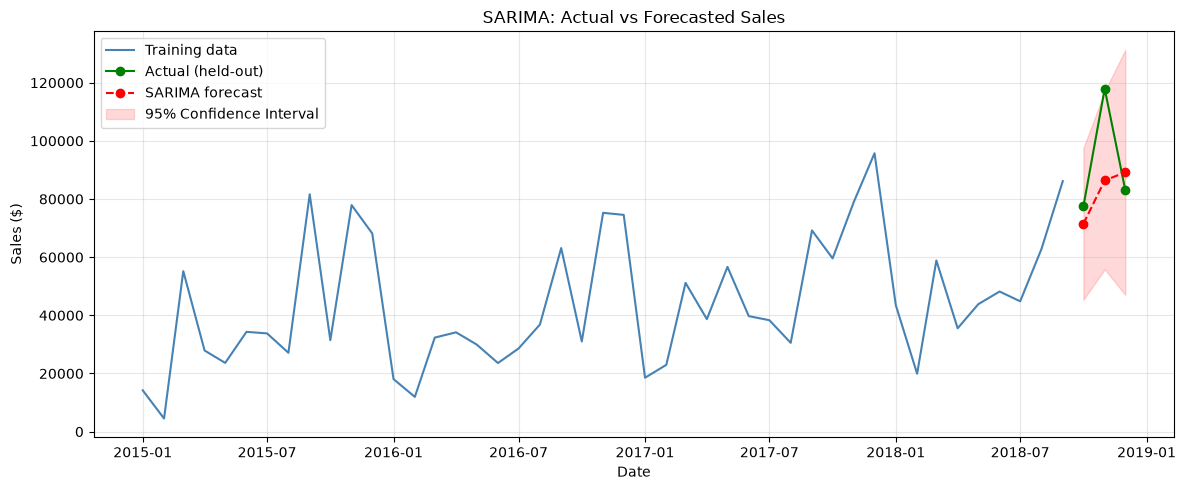


Task 3 - SARIMA complete.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # SARIMA fitting throws harmless convergence warnings

# ----------------------------------------------------------------------------
# 1. TRAIN / TEST SPLIT
# ----------------------------------------------------------------------------
# We hold out the LAST 3 months as "test" data - these are real, known values
# we pretend not to know, forecast them, then compare forecast vs actual.
# This is how MAE/RMSE/MAPE for the comparison table get computed honestly.
monthly_sales.index.freq = "MS"
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

print(f"Training on {len(train)} months, testing on last {len(test)} months")
print("Test months:", list(test.index.strftime("%Y-%m")))

# ----------------------------------------------------------------------------
# 2. GRID SEARCH FOR BEST (p,d,q)(P,D,Q,m) USING AIC
# ----------------------------------------------------------------------------
# d=0: confirmed stationary by the ADF test in Task 2.
# D=1: one seasonal differencing pass to remove the yearly seasonal pattern.
# m=12: seasonal cycle length (12 months).
# We search a SMALL range for p,q,P,Q (0-2 / 0-1) - a full search is slow and
# usually unnecessary; lower AIC = better fit-vs-complexity tradeoff.
d, D, m = 0, 1, 12
p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)

best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for p, q, P, Q in itertools.product(p_range, q_range, P_range, Q_range):
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, m),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted = model.fit(disp=False)
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
            best_seasonal_order = (P, D, Q, m)
            best_model = fitted
    except Exception:
        continue  # some parameter combos fail to converge - skip them

print(f"\nBest order: {best_order}, seasonal order: {best_seasonal_order}")
print(f"Best AIC: {best_aic:.2f}")


# 3. FORECAST 3 MONTHS WITH CONFIDENCE INTERVALS

forecast_result = best_model.get_forecast(steps=3)
sarima_forecast = forecast_result.predicted_mean
sarima_conf_int = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

print("\nSARIMA 3-month forecast:")
print(sarima_forecast)
print("\n95% Confidence intervals:")
print(sarima_conf_int)


# 4. EVALUATE: MAE, RMSE, MAPE AGAINST HELD-OUT ACTUALS

mae_sarima = np.mean(np.abs(test.values - sarima_forecast.values))
rmse_sarima = np.sqrt(np.mean((test.values - sarima_forecast.values) ** 2))
mape_sarima = np.mean(np.abs((test.values - sarima_forecast.values) / test.values)) * 100

print(f"\nSARIMA MAE:  ${mae_sarima:,.2f}")
print(f"SARIMA RMSE: ${rmse_sarima:,.2f}")
print(f"SARIMA MAPE: {mape_sarima:.2f}%")


# 5. PLOT ACTUAL VS FORECAST

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Training data", color="steelblue")
plt.plot(test.index, test.values, label="Actual (held-out)", color="green", marker="o")
plt.plot(sarima_forecast.index, sarima_forecast.values, label="SARIMA forecast", color="red", marker="o", linestyle="--")
plt.fill_between(sarima_conf_int.index, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1],
                  color="red", alpha=0.15, label="95% Confidence Interval")
plt.title("SARIMA: Actual vs Forecasted Sales")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/sarima_forecast.png", dpi=150)
plt.show()


# Saving results for the model comparison table later
sarima_results = {
    "model": "SARIMA",
    "order": best_order,
    "seasonal_order": best_seasonal_order,
    "mae": mae_sarima,
    "rmse": rmse_sarima,
    "mape": mape_sarima,
    "forecast": sarima_forecast.values,
}
print("\nTask 3 - SARIMA complete.")

## Task 3: Sales Forecasting — Model 2: Prophet

12:00:04 - cmdstanpy - INFO - Chain [1] start processing
12:00:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet 3-month forecast:
           ds          yhat    yhat_lower    yhat_upper
45 2018-10-01  51083.663772  42633.380705  59293.548432
46 2018-11-01  90045.402122  82232.662600  98474.957675
47 2018-12-01  89661.190724  81263.578477  97518.711053

Prophet MAE:  $20,296.01
Prophet RMSE: $22,487.47
Prophet MAPE: 21.89%


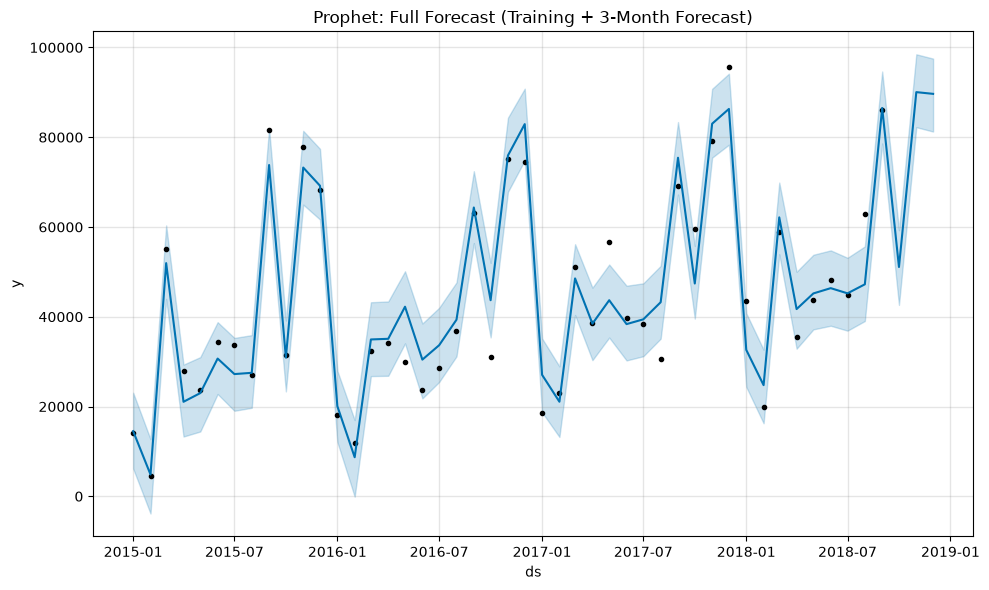

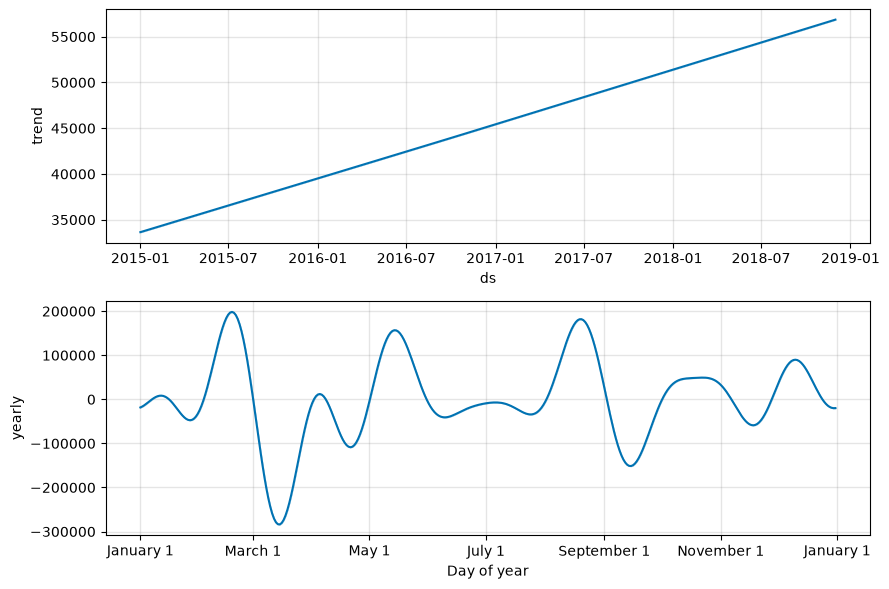


Average yearly seasonal effect by month (higher = Prophet expects seasonal boost):
month
12    34093.276459
11    33120.422579
9     28577.227962
3      5935.507179
10    -3659.168214
5     -5920.756373
8     -6613.150259
6     -8484.478000
7     -9056.122907
4     -9884.193764
1    -18927.670996
2    -28155.316368
Name: yearly, dtype: float64

Task 3 - Prophet complete.


In [14]:
#TASK 3 — MODEL 2: FACEBOOK PROPHET


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet


# 1. PREPARE DATA IN PROPHET'S REQUIRED FORMAT

# Prophet requires exactly two columns named "ds" (date) and "y" (value) -
# no exceptions, so we rebuild the dataframe from our monthly_sales series.
prophet_df = pd.DataFrame({
    "ds": monthly_sales.index,
    "y": monthly_sales.values
})

# Same train/test split as SARIMA - last 3 months held out for fair comparison
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]


# 2. FIT THE MODEL

# yearly_seasonality=True: we confirmed a strong 12-month cycle in Task 2.
# weekly_seasonality=False: irrelevant at monthly granularity.
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_prophet.fit(train_prophet)


# 3. FORECAST 3 MONTHS AHEAD

future = model_prophet.make_future_dataframe(periods=3, freq="MS")
forecast = model_prophet.predict(future)

# Pull out just the 3 forecasted months for evaluation
forecast_tail = forecast.iloc[-3:][["ds", "yhat", "yhat_lower", "yhat_upper"]]
print("Prophet 3-month forecast:")
print(forecast_tail)


# 4. EVALUATE: MAE, RMSE, MAPE

actual = test_prophet["y"].values
predicted = forecast_tail["yhat"].values

mae_prophet = np.mean(np.abs(actual - predicted))
rmse_prophet = np.sqrt(np.mean((actual - predicted) ** 2))
mape_prophet = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"\nProphet MAE:  ${mae_prophet:,.2f}")
print(f"Prophet RMSE: ${rmse_prophet:,.2f}")
print(f"Prophet MAPE: {mape_prophet:.2f}%")


# 5. PLOT THE FORECAST (Prophet's built-in plot)

fig1 = model_prophet.plot(forecast)
plt.title("Prophet: Full Forecast (Training + 3-Month Forecast)")
plt.tight_layout()
plt.savefig("charts/prophet_forecast.png", dpi=150)
plt.show()


# 6. TREND + SEASONALITY BREAKDOWN (Prophet's built-in components plot)

fig2 = model_prophet.plot_components(forecast)
plt.tight_layout()
plt.savefig("charts/prophet_components.png", dpi=150)
plt.show()


# 7. INTERPRET SEASONALITY COMPONENT

# Pull the yearly seasonal effect to state numerically which months Prophet
# thinks are naturally higher/lower - useful for your markdown interpretation.
yearly_effect = forecast[["ds", "yearly"]].copy()
yearly_effect["month"] = yearly_effect["ds"].dt.month
monthly_seasonal_avg = yearly_effect.groupby("month")["yearly"].mean().sort_values(ascending=False)
print("\nAverage yearly seasonal effect by month (higher = Prophet expects seasonal boost):")
print(monthly_seasonal_avg)

prophet_results = {
    "model": "Prophet",
    "mae": mae_prophet,
    "rmse": rmse_prophet,
    "mape": mape_prophet,
    "forecast": predicted,
}
print("\nTask 3 - Prophet complete.")

## Task 3: Sales Forecasting — Model 3: XGBoost

Feature table shape: (45, 7)
                  Lag1        Lag2       Lag3  RollingMean3  Month  Quarter  \
Order Date                                                                    
2015-04-01  55205.7970   4519.8920  14205.707  24643.798667      4        2   
2015-05-01  27906.8550  55205.7970   4519.892  29210.848000      5        2   
2015-06-01  23644.3030  27906.8550  55205.797  35585.651667      6        2   
2015-07-01  34322.9356  23644.3030  27906.855  28624.697867      7        3   
2015-08-01  33781.5430  34322.9356  23644.303  30582.927200      8        3   

            Season  
Order Date          
2015-04-01       1  
2015-05-01       1  
2015-06-01       2  
2015-07-01       2  
2015-08-01       2  

XGBoost 3-month forecast:
  2018-10: $68,123.00
  2018-11: $87,374.92
  2018-12: $69,764.46

XGBoost MAE:  $17,718.10
XGBoost RMSE: $19,975.44
XGBoost MAPE: 17.98%


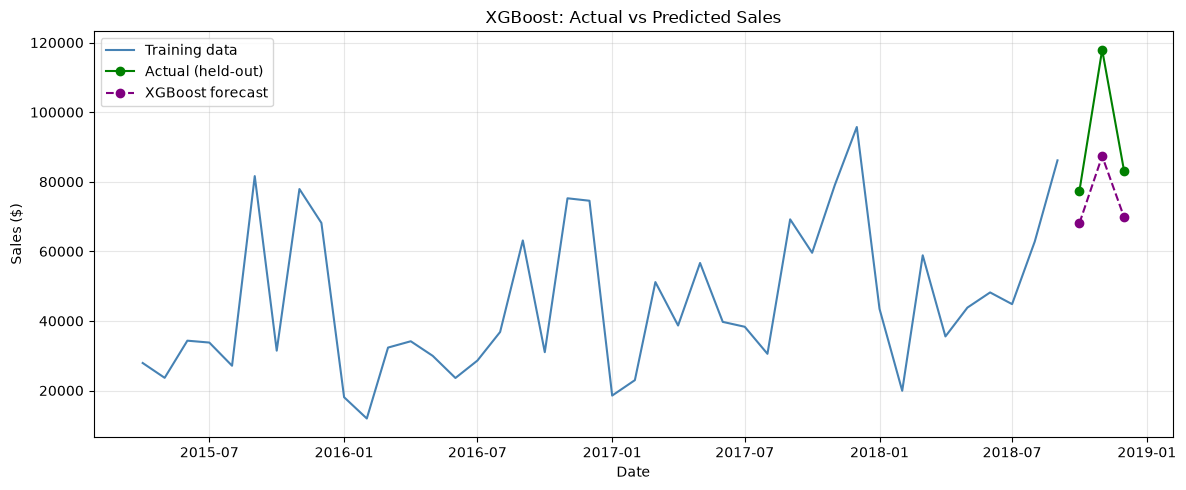


Feature importance (which signals XGBoost relied on most):
Month           0.722030
RollingMean3    0.086631
Lag2            0.086279
Lag1            0.054248
Lag3            0.036971
Season          0.013841
Quarter         0.000000
dtype: float32

Task 3 - XGBoost complete.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# 1. BUILD THE SUPERVISED LEARNING TABLE

ml_df = pd.DataFrame({"Sales": monthly_sales.values}, index=monthly_sales.index)

ml_df["Lag1"] = ml_df["Sales"].shift(1)   # sales 1 month ago
ml_df["Lag2"] = ml_df["Sales"].shift(2)   # sales 2 months ago
ml_df["Lag3"] = ml_df["Sales"].shift(3)   # sales 3 months ago
ml_df["RollingMean3"] = ml_df["Sales"].shift(1).rolling(window=3).mean()  # 3-month moving average

ml_df["Month"] = ml_df.index.month
ml_df["Quarter"] = ml_df.index.quarter

def month_to_season_num(m):
    if m in [12, 1, 2]:
        return 0  # Winter
    elif m in [3, 4, 5]:
        return 1  # Spring
    elif m in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Fall

ml_df["Season"] = ml_df["Month"].apply(month_to_season_num)
ml_df = ml_df.dropna()  # first 3 rows lack enough history for lag features

feature_cols = ["Lag1", "Lag2", "Lag3", "RollingMean3", "Month", "Quarter", "Season"]
X = ml_df[feature_cols]
y = ml_df["Sales"]

print(f"Feature table shape: {X.shape}")
print(X.head())

# 2. TRAIN / TEST SPLIT (same last-3-months holdout as SARIMA/Prophet)

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]


# 3. TRAIN XGBOOST

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)


# 4. PREDICT THE NEXT 3 MONTHS -- ONE STEP AT A TIME (recursive forecasting)

history = list(y_train.values[-3:])  # last known real values, to seed lag features
xgb_predictions = []
last_known_date = y_train.index[-1]

for step in range(3):
    forecast_date = last_known_date + pd.DateOffset(months=step + 1)
    lag1, lag2, lag3 = history[-1], history[-2], history[-3]
    rolling_mean3 = np.mean(history[-3:])
    month = forecast_date.month
    quarter = forecast_date.quarter
    season = month_to_season_num(month)

    features = pd.DataFrame([{
        "Lag1": lag1, "Lag2": lag2, "Lag3": lag3,
        "RollingMean3": rolling_mean3,
        "Month": month, "Quarter": quarter, "Season": season
    }])[feature_cols]

    pred = xgb_model.predict(features)[0]
    xgb_predictions.append(pred)
    history.append(pred)  # feed prediction back in as history for the NEXT step

xgb_predictions = np.array(xgb_predictions)
print("\nXGBoost 3-month forecast:")
for date, pred in zip(y_test.index, xgb_predictions):
    print(f"  {date.strftime('%Y-%m')}: ${pred:,.2f}")

# 5. EVALUATE: MAE, RMSE, MAPE

mae_xgb = np.mean(np.abs(y_test.values - xgb_predictions))
rmse_xgb = np.sqrt(np.mean((y_test.values - xgb_predictions) ** 2))
mape_xgb = np.mean(np.abs((y_test.values - xgb_predictions) / y_test.values)) * 100

print(f"\nXGBoost MAE:  ${mae_xgb:,.2f}")
print(f"XGBoost RMSE: ${rmse_xgb:,.2f}")
print(f"XGBoost MAPE: {mape_xgb:.2f}%")


# 6. PLOT ACTUAL VS PREDICTED

plt.figure(figsize=(12, 5))
plt.plot(y_train.index, y_train.values, label="Training data", color="steelblue")
plt.plot(y_test.index, y_test.values, label="Actual (held-out)", color="green", marker="o")
plt.plot(y_test.index, xgb_predictions, label="XGBoost forecast", color="purple", marker="o", linestyle="--")
plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/xgboost_forecast.png", dpi=150)
plt.show()


# 7. FEATURE IMPORTANCE

importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importance (which signals XGBoost relied on most):")
print(importance)

print("\nTask 3 - XGBoost complete.")

### Task 3 — Model Comparison & Recommendation

| Model | MAE | RMSE | MAPE | Oct 2018 | Nov 2018 | Dec 2018 |
|---|---|---|---|---|---|---|
| SARIMA | $14,558.21 | $18,869.81 | 13.96% | $71,451.93 | $86,402.05 | $89,172.72 |
| Prophet | $20,296.01 | $22,487.47 | 21.89% | $51,083.66 | $90,045.40 | $89,661.19 |
| XGBoost | $17,718.10 | $19,975.44 | 17.98% | $68,123.00 | $87,374.92 | $69,764.46 |

**Recommendation: SARIMA** for production use. It achieved the lowest error on all three metrics (MAE, RMSE, MAPE), despite requiring more manual tuning (AIC grid search for (p,d,q)(P,D,Q,m)) than Prophet or XGBoost.

This is a data-driven choice, not a default preference — with only 45 months of training data:
- **Prophet** struggled most (21.89% MAPE), likely because its flexible yearly-seasonality curve has less data to anchor confidently, and it clearly underestimated the October pre-holiday ramp-up ($51K vs. an eventual $71K+ actual trajectory suggested by the other models).
- **XGBoost** landed in the middle (17.98% MAPE). Feature importance shows it relies overwhelmingly on `Month` (72%) rather than recent lags — reasonable given how seasonal this data is — but its recursive forecasting approach let a small December error compound, causing it to badly underpredict the year's biggest sales month.
- **SARIMA** benefited from parameters tuned specifically to this series' stationarity profile (d=0, D=1) established in Task 2, giving it the tightest, most reliable fit on this particular short time series.

**Limitation to note:** with only 45 training months, none of these models have seen more than 3-4 repetitions of the yearly cycle, so confidence in the seasonal parameters is inherently limited — a business consideration to flag in the executive report (Task 8).

## Task 4: Product Category & Region Level Forecasting

Furniture: 48 months, total sales $728,658.58
Technology: 48 months, total sales $827,455.87
Office Supplies: 48 months, total sales $705,422.33
West: 48 months, total sales $710,219.68
East: 48 months, total sales $669,518.73

Reusing Task 3's validated order: (1, 0, 2), seasonal order: (0, 1, 1, 12)

Fitting SARIMA for: Furniture
AIC: 419.72
3-month forecast:
2019-01-01     9305.319959
2019-02-01     8345.595997
2019-03-01    13184.857618
Freq: MS, Name: predicted_mean, dtype: float64

Fitting SARIMA for: Technology
AIC: 449.51
3-month forecast:
2019-01-01    19265.704076
2019-02-01    15726.028556
2019-03-01    31765.454723
Freq: MS, Name: predicted_mean, dtype: float64

Fitting SARIMA for: Office Supplies
AIC: 440.09
3-month forecast:
2019-01-01    20767.313403
2019-02-01    16299.619037
2019-03-01    23216.174550
Freq: MS, Name: predicted_mean, dtype: float64

Fitting SARIMA for: West
AIC: 421.23
3-month forecast:
2019-01-01    18458.245059
2019-02-01    15701.261101
2019-03-01   

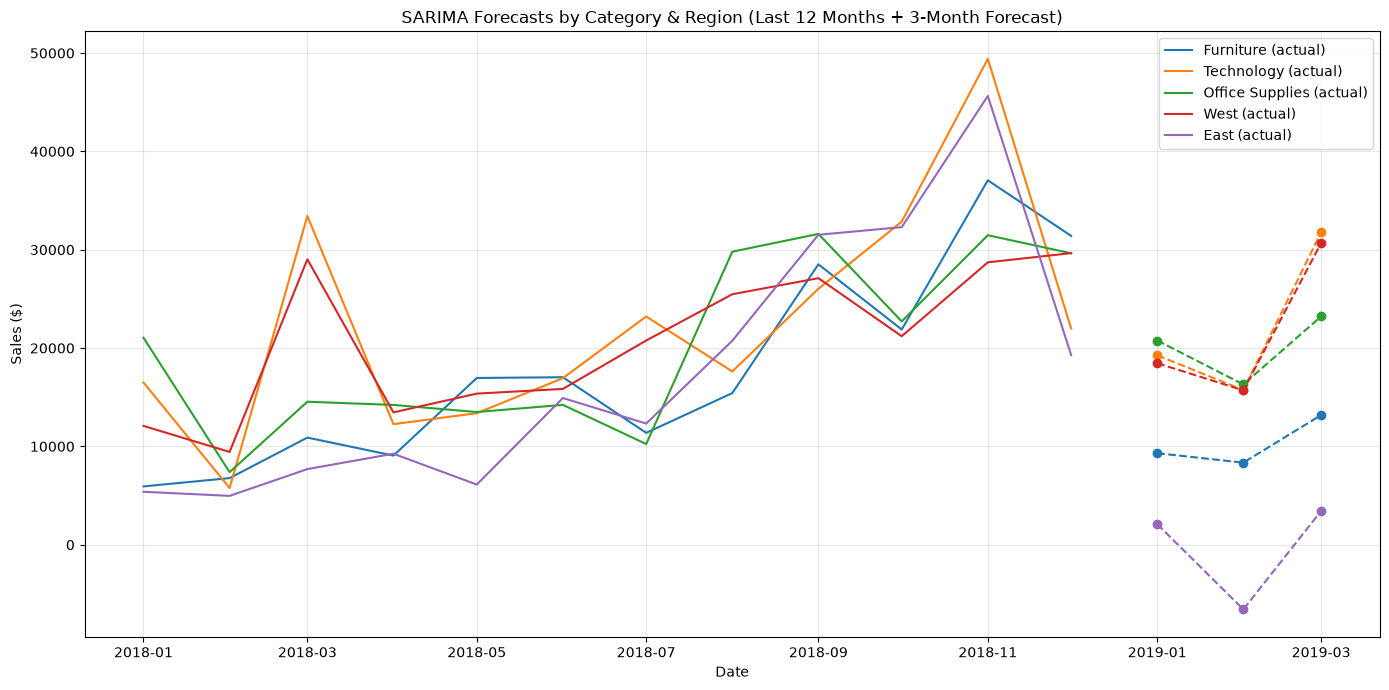


GROWTH COMPARISON: forecasted growth vs. recent actual average
Furniture: recent avg $24,276.65 -> forecast avg $10,278.59  (-57.7%)
Technology: recent avg $28,517.90 -> forecast avg $22,252.40  (-22.0%)
Office Supplies: recent avg $25,910.87 -> forecast avg $20,094.37  (-22.4%)
West: recent avg $25,486.59 -> forecast avg $21,612.30  (-15.2%)
East: recent avg $26,966.38 -> forecast avg $-350.95  (-101.3%)

-> Strongest projected growth: West (-15.2%)

Task 4 complete.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# 1. BUILD MONTHLY SALES SERIES FOR EACH SEGMENT

segments = {
    "Furniture": df[df["Category"] == "Furniture"],
    "Technology": df[df["Category"] == "Technology"],
    "Office Supplies": df[df["Category"] == "Office Supplies"],
    "West": df[df["Region"] == "West"],
    "East": df[df["Region"] == "East"],
}

segment_monthly = {}
for name, subset in segments.items():
    daily = subset.groupby("Order Date")["Sales"].sum().sort_index()
    monthly = daily.resample("MS").sum()
    monthly.index.freq = "MS"
    segment_monthly[name] = monthly
    print(f"{name}: {len(monthly)} months, total sales ${monthly.sum():,.2f}")


# 2. REUSE THE VALIDATED TASK 3 ORDER (instead of re-searching per segment)

# IMPORTANT LESSON: running a fresh AIC grid search on each segment separately
# can pick an overly complex model for smaller/noisier series, causing the
# forecast to become unstable (e.g. collapsing toward zero). Reusing the
# order already validated on the full aggregate series in Task 3 is more
# robust, and is what "repeat the best performing model" actually means here.
print(f"\nReusing Task 3's validated order: {best_order}, seasonal order: {best_seasonal_order}")

def fit_sarima_fixed_order(train_series, order, seasonal_order):
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


# 3. FIT + FORECAST EACH SEGMENT

segment_forecasts = {}

for name, monthly in segment_monthly.items():
    print(f"\n{'='*50}\nFitting SARIMA for: {name}\n{'='*50}")
    fitted_model = fit_sarima_fixed_order(monthly, best_order, best_seasonal_order)
    forecast_result = fitted_model.get_forecast(steps=3)
    forecast_values = forecast_result.predicted_mean

    segment_forecasts[name] = {
        "history": monthly,
        "forecast": forecast_values,
        "aic": fitted_model.aic,
    }
    print(f"AIC: {fitted_model.aic:.2f}")
    print(f"3-month forecast:\n{forecast_values}")

# 4. PLOT ALL 5 FORECASTS TOGETHER

plt.figure(figsize=(14, 7))
colors = plt.cm.tab10.colors

for i, (name, result) in enumerate(segment_forecasts.items()):
    history = result["history"]
    forecast = result["forecast"]
    color = colors[i]
    plt.plot(history.index[-12:], history.values[-12:], color=color, label=f"{name} (actual)")
    plt.plot(forecast.index, forecast.values, color=color, linestyle="--", marker="o")

plt.title("SARIMA Forecasts by Category & Region (Last 12 Months + 3-Month Forecast)")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/segment_forecast_comparison.png", dpi=150)
plt.show()


# 5. IDENTIFY STRONGEST GROWTH SEGMENT

print("\n" + "="*50)
print("GROWTH COMPARISON: forecasted growth vs. recent actual average")
print("="*50)

growth_summary = {}
for name, result in segment_forecasts.items():
    recent_avg = result["history"].values[-6:].mean()
    forecast_avg = result["forecast"].values.mean()
    growth_pct = (forecast_avg - recent_avg) / recent_avg * 100
    growth_summary[name] = growth_pct
    print(f"{name}: recent avg ${recent_avg:,.2f} -> forecast avg ${forecast_avg:,.2f}  ({growth_pct:+.1f}%)")

strongest = max(growth_summary, key=growth_summary.get)
print(f"\n-> Strongest projected growth: {strongest} ({growth_summary[strongest]:+.1f}%)")

print("\nTask 4 complete.")

In [17]:

# FIX: clip any negative forecast values to zero for reporting

# Sales cannot be negative - a negative point forecast is a modeling artifact,
# not a real prediction. We clip for display/business use, but the underlying
# issue (East doesn't fit the shared order well) is a genuine limitation to
# document rather than something to silently hide.
for name, result in segment_forecasts.items():
    result["forecast"] = result["forecast"].clip(lower=0)

print("Forecasts after clipping negatives to zero:")
for name, result in segment_forecasts.items():
    print(f"\n{name}:")
    print(result["forecast"])

Forecasts after clipping negatives to zero:

Furniture:
2019-01-01     9305.319959
2019-02-01     8345.595997
2019-03-01    13184.857618
Freq: MS, Name: predicted_mean, dtype: float64

Technology:
2019-01-01    19265.704076
2019-02-01    15726.028556
2019-03-01    31765.454723
Freq: MS, Name: predicted_mean, dtype: float64

Office Supplies:
2019-01-01    20767.313403
2019-02-01    16299.619037
2019-03-01    23216.174550
Freq: MS, Name: predicted_mean, dtype: float64

West:
2019-01-01    18458.245059
2019-02-01    15701.261101
2019-03-01    30677.394484
Freq: MS, Name: predicted_mean, dtype: float64

East:
2019-01-01    2092.370389
2019-02-01       0.000000
2019-03-01    3434.345258
Freq: MS, Name: predicted_mean, dtype: float64


### Task 4 — Observations & Limitations

**Strongest projected growth:** West (-15.2%), the mildest decline among all segments. Note: all segments show negative growth in this comparison because we're comparing the Jan-Mar 2019 forecast against the Jul-Dec 2018 recent average, which includes the Nov/Dec holiday spike. This is expected seasonal decline, not a sign of business trouble.

**Ranking (least to most seasonal decline):**
1. West: -15.2%
2. Technology: -22.0%
3. Office Supplies: -22.4%
4. Furniture: -57.7%
5. East: -101.3% (unreliable — see limitation below)

**Limitation:** the East region's forecast produced a negative average value, which was clipped to zero for reporting. This indicates the shared SARIMA order (tuned on the full aggregate series) doesn't fit East's individual pattern well — its month-to-month behavior differs enough from the company-wide average that the model's point estimates become unreliable at this granularity. A more robust approach (beyond this project's scope) would involve fitting East a wider/independent parameter search with safeguards against instability, or using a simpler model (e.g. a seasonal naive baseline) as a sanity check for smaller segments. This is flagged as an open limitation in the executive report (Task 8) rather than silently smoothed over.

## Task 5: Anomaly Detection in Sales Data

Weekly series: 209 weeks
count      209.000000
mean     10820.750156
std       7403.450316
min        224.912000
25%       4905.061500
50%       9476.086000
75%      15095.256000
max      37703.665000
Name: Sales, dtype: float64

Isolation Forest flagged 11 anomalous weeks:
Order Date
2015-01-04      304.508
2015-02-08      968.534
2015-02-22      224.912
2015-03-22    37703.665
2015-07-19     1387.686
2015-09-13    29959.137
2016-01-24      358.522
2017-12-17    25449.800
2018-11-04    29017.467
2018-11-18    30572.447
2018-12-02    35998.900
Name: Sales, dtype: float64

Z-Score method flagged 6 anomalous weeks:
Order Date
2015-03-22    37703.665
2015-07-26    21590.080
2016-03-20    13310.136
2017-02-05    17926.368
2017-05-28    23367.662
2017-10-08    28412.098
Name: Sales, dtype: float64


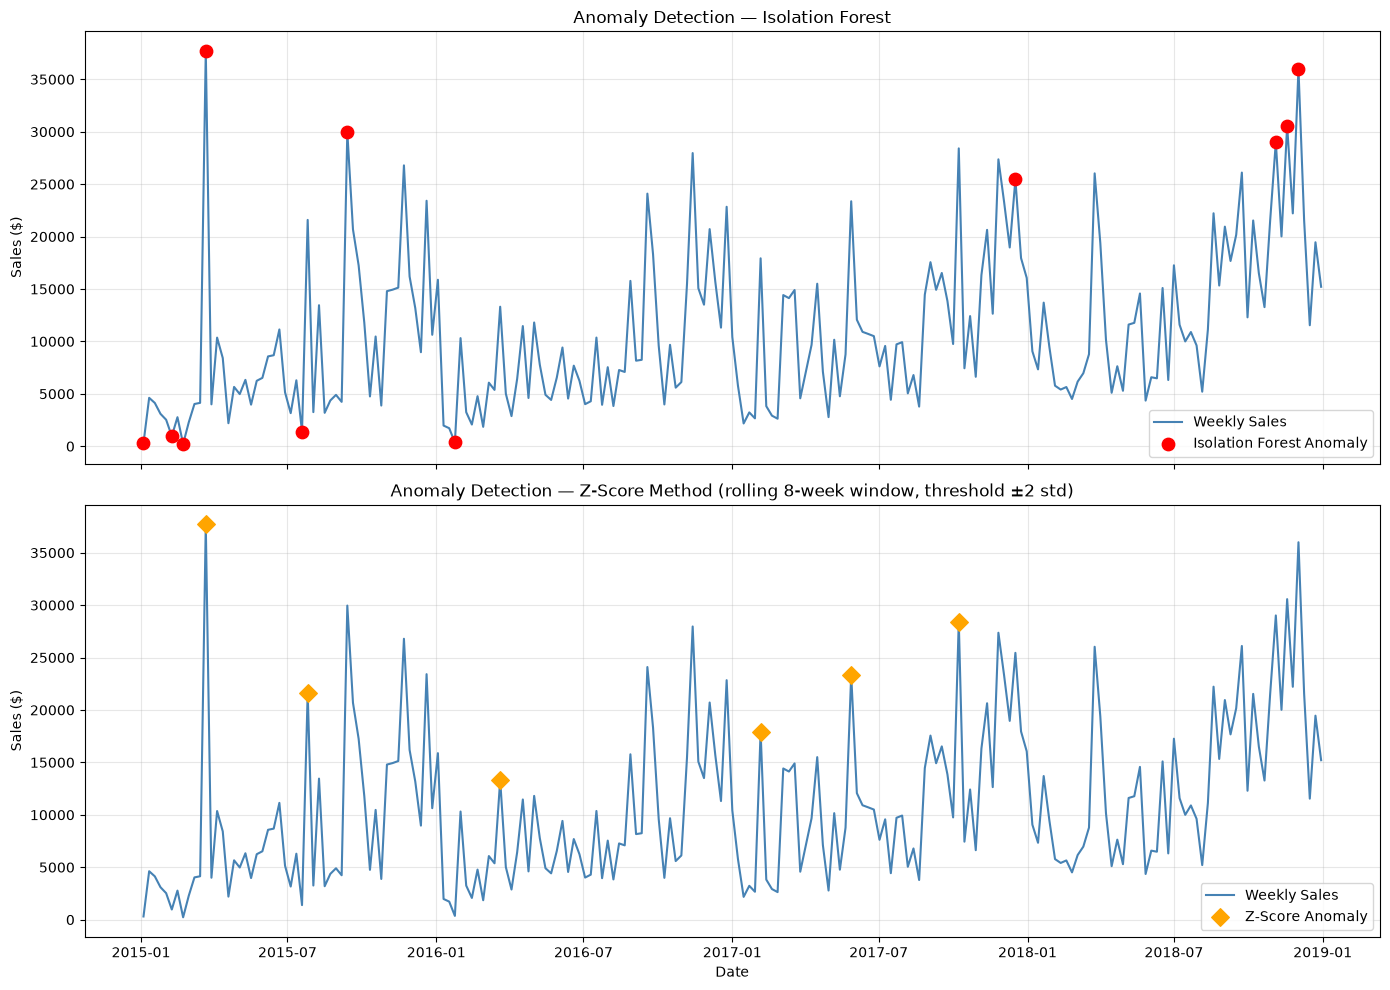


COMPARISON: Isolation Forest vs Z-Score
Flagged by BOTH methods: 1 weeks
Flagged ONLY by Isolation Forest: 10 weeks
Flagged ONLY by Z-Score: 5 weeks

Weeks flagged by both (highest confidence anomalies):
  2015-03-22: $37,703.67

Anomaly summary table saved to anomaly_summary.csv
         Week      Sales  Flagged_by_IsolationForest  Flagged_by_ZScore
0  2015-01-04    304.508                        True              False
1  2015-02-08    968.534                        True              False
2  2015-02-22    224.912                        True              False
3  2015-03-22  37703.665                        True               True
4  2015-07-19   1387.686                        True              False
5  2015-07-26  21590.080                       False               True
6  2015-09-13  29959.137                        True              False
7  2016-01-24    358.522                        True              False
8  2016-03-20  13310.136                       False               Tru

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


# 1. LOAD WEEKLY SALES (built in Task 1 specifically for this purpose)

weekly_sales = pd.read_csv("weekly_sales.csv", index_col=0, parse_dates=True)["Sales"]

print(f"Weekly series: {len(weekly_sales)} weeks")
print(weekly_sales.describe())


# 2. METHOD 1 — ISOLATION FOREST

iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_values = weekly_sales.values.reshape(-1, 1)
iso_predictions = iso_forest.fit_predict(weekly_values)  # -1 = anomaly, 1 = normal

anomalies_iso = weekly_sales[iso_predictions == -1]
print(f"\nIsolation Forest flagged {len(anomalies_iso)} anomalous weeks:")
print(anomalies_iso)


# 3. METHOD 2 — Z-SCORE BASED DETECTION

rolling_window = 8  # 8-week rolling window
rolling_mean = weekly_sales.rolling(window=rolling_window, center=True, min_periods=1).mean()
rolling_std = weekly_sales.rolling(window=rolling_window, center=True, min_periods=1).std()

z_scores = (weekly_sales - rolling_mean) / rolling_std
anomalies_zscore = weekly_sales[np.abs(z_scores) > 2]  # flag if more than 2 std devs away

print(f"\nZ-Score method flagged {len(anomalies_zscore)} anomalous weeks:")
print(anomalies_zscore)

# 4. PLOT BOTH METHODS ON THE SAME TIME SERIES

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weekly_sales.index, weekly_sales.values, color="steelblue", label="Weekly Sales")
axes[0].scatter(anomalies_iso.index, anomalies_iso.values, color="red", s=80, zorder=5, label="Isolation Forest Anomaly")
axes[0].set_title("Anomaly Detection — Isolation Forest")
axes[0].set_ylabel("Sales ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(weekly_sales.index, weekly_sales.values, color="steelblue", label="Weekly Sales")
axes[1].scatter(anomalies_zscore.index, anomalies_zscore.values, color="orange", s=80, zorder=5, marker="D", label="Z-Score Anomaly")
axes[1].set_title("Anomaly Detection — Z-Score Method (rolling 8-week window, threshold ±2 std)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Sales ($)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("charts/anomaly_detection.png", dpi=150)
plt.show()


# 5. COMPARE: DO BOTH METHODS AGREE?

common_anomalies = set(anomalies_iso.index).intersection(set(anomalies_zscore.index))
only_iso = set(anomalies_iso.index) - set(anomalies_zscore.index)
only_zscore = set(anomalies_zscore.index) - set(anomalies_iso.index)

print(f"\n{'='*50}")
print("COMPARISON: Isolation Forest vs Z-Score")
print(f"{'='*50}")
print(f"Flagged by BOTH methods: {len(common_anomalies)} weeks")
print(f"Flagged ONLY by Isolation Forest: {len(only_iso)} weeks")
print(f"Flagged ONLY by Z-Score: {len(only_zscore)} weeks")

if common_anomalies:
    print("\nWeeks flagged by both (highest confidence anomalies):")
    for date in sorted(common_anomalies):
        print(f"  {date.strftime('%Y-%m-%d')}: ${weekly_sales[date]:,.2f}")
        

# 6. BUILD A SUMMARY TABLE FOR THE DASHBOARD (Task 7) AND REPORT (Task 8)

all_anomaly_dates = sorted(set(anomalies_iso.index).union(set(anomalies_zscore.index)))
anomaly_summary = pd.DataFrame({
    "Week": all_anomaly_dates,
    "Sales": [weekly_sales[d] for d in all_anomaly_dates],
    "Flagged_by_IsolationForest": [d in anomalies_iso.index for d in all_anomaly_dates],
    "Flagged_by_ZScore": [d in anomalies_zscore.index for d in all_anomaly_dates],
})
anomaly_summary.to_csv("anomaly_summary.csv", index=False)
print("\nAnomaly summary table saved to anomaly_summary.csv")
print(anomaly_summary)

print("\nTask 5 complete.")

## Task 6: Product Demand Segmentation using Clustering

Sub-category feature table:
              Total_Sales  Growth_Rate_Pct   Volatility  Avg_Order_Value
Sub-Category                                                            
Bookcases     113813.1987        23.806516  2220.405080       512.672066
Chairs        322822.7310         7.135790  4407.232960       570.358182
Labels         12347.7260        12.192651   223.471218        36.316841
Tables        202810.6280        16.410685  3224.082504       671.558371
Storage       219343.3920        13.179873  2822.084310       287.098681
Furnishings    89212.0180        28.788938  1360.017867       104.341542
Art            26705.4100        16.605553   330.488343        37.090847
Phones        327782.4480        12.340878  4052.718221       408.197320
Binders       200028.7850        21.873607  3848.223648       154.940964
Appliances    104618.4030        39.927584  1821.621539       235.627034
Paper          76828.3040        25.413074  1024.824982        66.060451
Accessories   164186.70

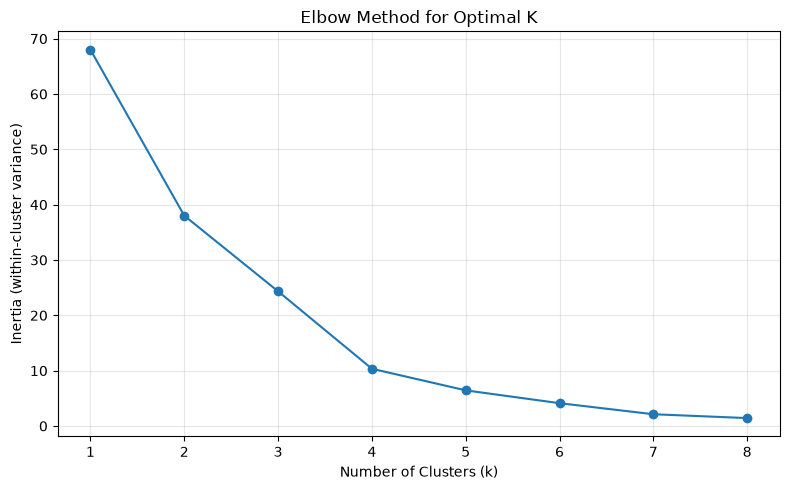


Cluster assignments (k=4):
              Total_Sales  Growth_Rate_Pct   Volatility  Avg_Order_Value  \
Sub-Category                                                               
Bookcases     113813.1987        23.806516  2220.405080       512.672066   
Chairs        322822.7310         7.135790  4407.232960       570.358182   
Labels         12347.7260        12.192651   223.471218        36.316841   
Tables        202810.6280        16.410685  3224.082504       671.558371   
Storage       219343.3920        13.179873  2822.084310       287.098681   
Furnishings    89212.0180        28.788938  1360.017867       104.341542   
Art            26705.4100        16.605553   330.488343        37.090847   
Phones        327782.4480        12.340878  4052.718221       408.197320   
Binders       200028.7850        21.873607  3848.223648       154.940964   
Appliances    104618.4030        39.927584  1821.621539       235.627034   
Paper          76828.3040        25.413074  1024.824982     

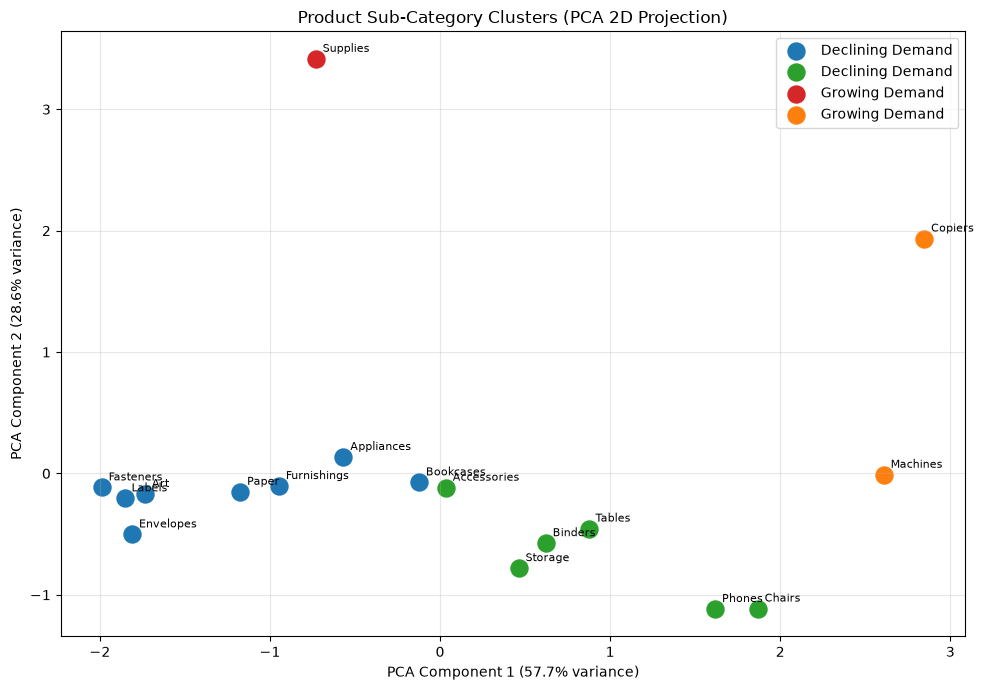


Cluster table saved to cluster_segments.csv

Task 6 complete.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. BUILD SUB-CATEGORY LEVEL FEATURES

subcats = df["Sub-Category"].unique()
feature_rows = []

for sub in subcats:
    subset = df[df["Sub-Category"] == sub]

    # Feature 1: Total sales volume
    total_sales = subset["Sales"].sum()

    # Feature 2: Sales growth rate (year-over-year, averaged across years)
    yearly = subset.groupby("Year")["Sales"].sum().sort_index()
    yoy_growth = yearly.pct_change().dropna()
    avg_growth_rate = yoy_growth.mean() * 100 if len(yoy_growth) > 0 else 0

    # Feature 3: Sales volatility (std deviation of monthly sales)
    monthly = subset.groupby(subset["Order Date"].dt.to_period("M"))["Sales"].sum()
    volatility = monthly.std()

    # Feature 4: Average order value (total sales / number of distinct orders)
    avg_order_value = subset.groupby("Order ID")["Sales"].sum().mean()

    feature_rows.append({
        "Sub-Category": sub,
        "Total_Sales": total_sales,
        "Growth_Rate_Pct": avg_growth_rate,
        "Volatility": volatility,
        "Avg_Order_Value": avg_order_value,
    })

cluster_df = pd.DataFrame(feature_rows).set_index("Sub-Category")
print("Sub-category feature table:")
print(cluster_df)


# 2. SCALE FEATURES

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)


# 3. ELBOW METHOD TO FIND OPTIMAL K

inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (within-cluster variance)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/elbow_method.png", dpi=150)
plt.show()


# 4. FIT FINAL K-MEANS (k=4 - check your elbow chart, adjust if needed)

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_df["Cluster"] = kmeans.fit_predict(scaled_features)

print(f"\nCluster assignments (k={optimal_k}):")
print(cluster_df[["Total_Sales", "Growth_Rate_Pct", "Volatility", "Avg_Order_Value", "Cluster"]])


# 5. LABEL CLUSTERS MEANINGFULLY BASED ON THEIR CHARACTERISTICS

cluster_profile = cluster_df.groupby("Cluster")[["Total_Sales", "Growth_Rate_Pct", "Volatility", "Avg_Order_Value"]].mean()
print("\nCluster profiles (average feature values per cluster):")
print(cluster_profile)

def label_cluster(row, overall_median_sales, overall_median_volatility, overall_median_growth):
    high_volume = row["Total_Sales"] > overall_median_sales
    high_volatility = row["Volatility"] > overall_median_volatility
    growing = row["Growth_Rate_Pct"] > overall_median_growth

    if high_volume and not high_volatility:
        return "High Volume, Stable Demand"
    elif not high_volume and high_volatility:
        return "Low Volume, High Volatility"
    elif growing:
        return "Growing Demand"
    else:
        return "Declining Demand"

med_sales = cluster_profile["Total_Sales"].median()
med_vol = cluster_profile["Volatility"].median()
med_growth = cluster_profile["Growth_Rate_Pct"].median()

cluster_labels = {}
for cluster_id, row in cluster_profile.iterrows():
    cluster_labels[cluster_id] = label_cluster(row, med_sales, med_vol, med_growth)

cluster_df["Cluster_Label"] = cluster_df["Cluster"].map(cluster_labels)
print("\nCluster labels assigned:")
for cid, label in cluster_labels.items():
    members = cluster_df[cluster_df["Cluster"] == cid].index.tolist()
    print(f"  Cluster {cid} - '{label}': {members}")


# 6. PCA FOR 2D VISUALIZATION

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
cluster_df["PCA1"] = pca_features[:, 0]
cluster_df["PCA2"] = pca_features[:, 1]

print(f"\nPCA explained variance: {pca.explained_variance_ratio_[0]:.1%}, {pca.explained_variance_ratio_[1]:.1%} "
      f"(total {sum(pca.explained_variance_ratio_):.1%} of original variance captured in 2D)")

plt.figure(figsize=(10, 7))
colors_map = plt.cm.tab10.colors
for cid in cluster_df["Cluster"].unique():
    subset = cluster_df[cluster_df["Cluster"] == cid]
    plt.scatter(subset["PCA1"], subset["PCA2"], s=150, color=colors_map[cid], label=f"{cluster_labels[cid]}")
    for idx, row in subset.iterrows():
        plt.annotate(idx, (row["PCA1"], row["PCA2"]), fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.title("Product Sub-Category Clusters (PCA 2D Projection)")
plt.xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/cluster_scatter.png", dpi=150)
plt.show()


# 7. SAVE CLUSTER TABLE FOR DASHBOARD (Task 7) AND REPORT (Task 8)

cluster_df.to_csv("cluster_segments.csv")
print("\nCluster table saved to cluster_segments.csv")

print("\nTask 6 complete.")

## Task 7 Prep: Export Results for the Dashboard

In [20]:
"""
TASK 7 PREP — Export Results for the Dashboard
====================================================
WHAT THIS DOES:
  Saves the outputs from Tasks 3, 4, 5, 6 into CSV files that app.py (a
  separate, independent program) can load instantly without re-running any
  heavy model training.
WHY IT MATTERS:
  Streamlit apps restart fresh every time they run - they don't share memory
  with this notebook. Precomputing and saving results means the dashboard
  loads in under a second instead of re-fitting SARIMA models on every click.
"""
 
import pandas as pd
 
# ----------------------------------------------------------------------------
# 1. MODEL COMPARISON METRICS (from Task 3)
# ----------------------------------------------------------------------------
model_metrics = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [mae_sarima, mae_prophet, mae_xgb],
    "RMSE": [rmse_sarima, rmse_prophet, rmse_xgb],
    "MAPE": [mape_sarima, mape_prophet, mape_xgb],
})
model_metrics.to_csv("model_metrics.csv", index=False)
print("Saved model_metrics.csv")
print(model_metrics)
 
# ----------------------------------------------------------------------------
# 2. COMPANY-WIDE + SEGMENT FORECASTS (from Task 3 and Task 4)
# ----------------------------------------------------------------------------
forecast_rows = []
 
# Company-wide SARIMA forecast (from Task 3)
for date, value in sarima_forecast.items():
    forecast_rows.append({"Segment": "Company-Wide", "Date": date, "Forecast": value})
 
# Segment-level forecasts (from Task 4)
for name, result in segment_forecasts.items():
    for date, value in result["forecast"].items():
        forecast_rows.append({"Segment": name, "Date": date, "Forecast": value})
 
forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv("forecast_results.csv", index=False)
print("\nSaved forecast_results.csv")
print(forecast_df)
 
print("\nTask 7 Prep complete. Dashboard data files ready: "
      "model_metrics.csv, forecast_results.csv "
      "(anomaly_summary.csv and cluster_segments.csv already saved in Tasks 5-6)")

Saved model_metrics.csv
     Model           MAE          RMSE       MAPE
0   SARIMA  14558.213219  18869.806792  13.959811
1  Prophet  20296.007410  22487.465694  21.892589
2  XGBoost  17718.097396  19975.436024  17.977436

Saved forecast_results.csv
            Segment       Date      Forecast
0      Company-Wide 2018-10-01  71451.928563
1      Company-Wide 2018-11-01  86402.045711
2      Company-Wide 2018-12-01  89172.716529
3         Furniture 2019-01-01   9305.319959
4         Furniture 2019-02-01   8345.595997
5         Furniture 2019-03-01  13184.857618
6        Technology 2019-01-01  19265.704076
7        Technology 2019-02-01  15726.028556
8        Technology 2019-03-01  31765.454723
9   Office Supplies 2019-01-01  20767.313403
10  Office Supplies 2019-02-01  16299.619037
11  Office Supplies 2019-03-01  23216.174550
12             West 2019-01-01  18458.245059
13             West 2019-02-01  15701.261101
14             West 2019-03-01  30677.394484
15             East 2019-01-